## Code


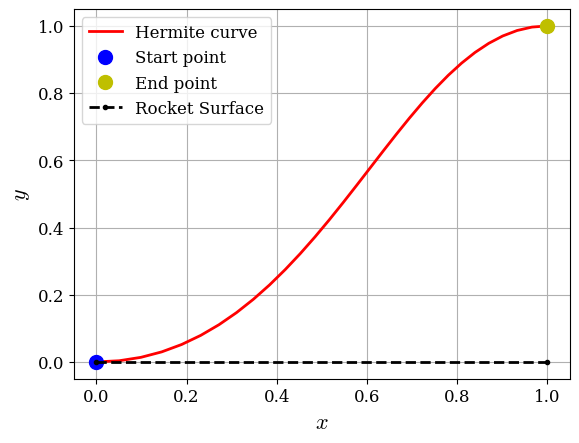

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# sudo apt install python3-pygame
#https://www.youtube.com/watch?v=hG0p4XgePSA
#https://www.youtube.com/watch?v=jqbr39dhyWQ

def hermit(X0,X1,X0p,X1p,nps):
    t = np.linspace(0,1,nps)
    # https://www.youtube.com/watch?v=hG0p4XgePSA
    # bfun =  np.array(
    #   [[2,1,-2,1],
    #   [-3,-2,3,-1],
    #   [0,1,0,0],
    #   [1,0,0,0]]);
    # slopes = np.array([X0,X1,X0p,X1p]);
    # M = np.dot(bfun,slopes)
    if X1 < -2:
        X1 = -2
    if X1 > 2:
        X1 = 2
    # points ---------------------------
    af = 2*t**3 - 3*t**2 + 1;
    bf = t**3 - 2*t**2 + t;
    cf = -2*t**3 + 3*t**2;
    df = t**3 - t**2;
    xt = af*X0 + bf*X0p + cf*X1 + df*X1p;
    # derivatives ----------------------
    daf = 6*t**2 -6*t
    dbf = 3*t**2 - 4*t + 1
    dcf = -6*t**2 + 6*t
    ddf = 3*t**2 - 2*t
    xdt = daf*X0 + dbf*X0p + dcf*X1 + ddf*X1p

    return xt, xdt

# =========================================================
# number of points per hermite curve----------
nps = 30;
# initial point and derivatives --------------
x0 = 0.;
y0 = 0.0;
x0p = 1.50;
y0p = 0;
# end point and derivatives ------------------
xe = 1.;
ye = 1;
xep =1;
yep = 0.;
# points and derivatives generation ----------
xpts, xdpts = hermit(x0,xe,x0p,xep,nps)
ypts, ydpts = hermit(y0,ye,y0p,yep,nps)
# local angles -------------------------------
theta = pi/2 + np.arctan2(ydpts,xdpts) ;
# print('thteta ', theta*180/pi)

# number of triangles ------------------------
nV=5
# triangle vertex storage --------------------
XV = np.zeros((nV,4))
YV = np.zeros((nV,4))
# print(XV)
# list of indexs of points ------- see 88 ----
# lsi = 3*np.array([1,4,6,8]).astype(int)
lsi = np.array([2,8,16,21,26]).astype(int)
# lsi = np.array([2,12,21]).astype(int)

"""
# triangle gneration function call -----------
for i in range(lsi.size):
    c = lsi[i]
    xc = xpts[c];
    yc = ypts[c];
    ang = theta[c];
    sc = 1.5 - i/nV
    xv,yv = triangle(xc,yc,sc,ang)
    XV[i,:] = xv
    YV[i,:] = yv
# print('XV = ',XV)
# xv,yv = triangle(0.5,0.5,1.0,)
"""
# plots -------------------------------------
# Rocket surface
xs_r = [0,1]
rs = [0,0]
#plt.style.use('dark_background')

plt.rcParams.update({
    "text.usetex": False,      # IMPORTANTE
    "font.family": "serif",
    "mathtext.fontset": "cm",  # Computer Modern
    #"font.size": 12,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2
})



fig0 = plt.figure(0)
ax = plt.axes();
plt.plot(xpts,ypts,'r', label = r"Hermite curve") # hermite line
plt.plot(x0,y0,'bo',markersize=10, label = r"Start point") # start marker
plt.plot(xe,ye,'yo',markersize=10, label = r"End point") # end marker
plt.plot(xs_r, rs, color='black', linestyle='--', marker='.', label = r"Rocket Surface") # rocket surface
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
x0ps = np.linspace(0.5, 3.25, 30)
xeps = np.linspace(0.5, 3.25, 30)

xpts_list = []
xdpts_list = []


for x0p in x0ps:
    for xep in xeps:
        xpts, xdpts = hermit(x0,xe,x0p,xep,nps)
        xpts_list.append(xpts)
        xdpts_list.append(xdpts)

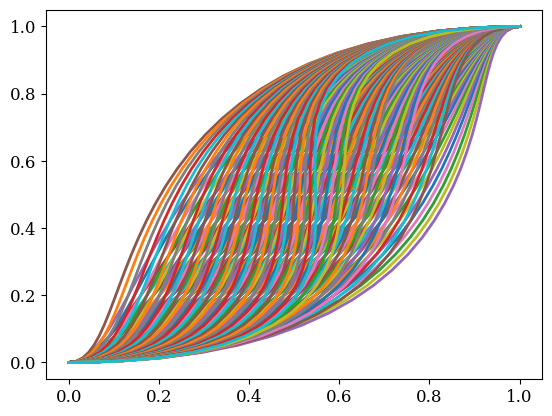

In [ ]:
for i in range(0, len(xpts_list), 5):
    plt.plot(xpts_list[i], ypts)
plt.show()

In [ ]:
from sympy import symbols, diff, simplify

def hermite_t(X0, X1, X0p, X1p):

    t = symbols('t')
    X0P = symbols('X0p')
    X1P = symbols('X1p')

    # points
    X0 = max(min(X0, 2), -2)

    # clamp
    X1 = max(min(X1, 2), -2)

    # basis functions
    af = 2*t**3 - 3*t**2 + 1
    bf = t**3 - 2*t**2 + t
    cf = -2*t**3 + 3*t**2
    df = t**3 - t**2

    # interpolation
    xt = af*X0 + bf*X0p + cf*X1 + df*X1p

    # symbolic derivative
    xdt = simplify(diff(xt, t))

    return xt, xdt

In [ ]:
t = symbols('t')
X0p = symbols('X0p')
Xep = symbols('Xep')
xt, xdt = hermite_t(x0, xe, X0p, Xep)
yt, ydt = hermite_t(y0, ye, 0, 0)

dxdy = xdt/ydt
dxdy_2 = diff(dxdy, t)/ydt
dxdy_2 = simplify(dxdy_2)
print(dxdy_2)


(X0p*t**2 - 2*X0p*t + X0p - Xep*t**2)/(36*t**3*(t**3 - 3*t**2 + 3*t - 1))


In [ ]:
import sympy as sp
ts = np.linspace(0,1,10)
zeros_num = sp.solve(dxdy_2.subs(t, ts), X0p)
print(zeros_num)



SympifyError: SympifyError: array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])